In [ ]:
!pip install doubleml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 603.5/603.5 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 72.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.3/230.3 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 4.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from doubleml import datasets

# Try different API variations depending on your DoubleML version
try:
    df = datasets.fetch_401K(return_type="DataFrame")
except TypeError:
    df = datasets.fetch_401K("DataFrame")

# Save locally
df.to_csv("pension_401k.csv", index=False)
print("Saved: pension_401k.csv")

Saved: pension_401k.csv


In [ ]:
import pandas as pd

df = pd.read_csv("pension_401k.csv")

# Rescale outcome to thousands of dollars
df["net_tfa_k"] = df["net_tfa"] / 1000
df = df.drop(columns=["net_tfa"])

df.shape

(9915, 14)

In [ ]:
df.columns

Index(['nifa', 'tw', 'age', 'inc', 'fsize', 'educ', 'db', 'marr', 'twoearn',
       'e401', 'p401', 'pira', 'hown', 'net_tfa_k'],
      dtype='object')

In [ ]:
df[["net_tfa_k", "p401", "e401"]].describe()

,net_tfa_k,p401,e401
count,9915.000000,9915.000000,9915.000000
mean,18.051535,0.261624,0.371357
std,63.522502,0.439541,0.483192
min,-502.302000,0.000000,0.000000
25%,-0.500000,0.000000,0.000000
50%,1.499000,0.000000,0.000000
75%,16.524500,1.000000,1.000000
max,1536.798000,1.000000,1.000000


In [ ]:
df["p401"].mean(), df["e401"].mean()

(np.float64(0.2616238023197176), np.float64(0.3713565305093293))

In [ ]:
df.isna().sum()

,0
nifa,0
tw,0
age,0
inc,0
fsize,0
educ,0
db,0
marr,0
twoearn,0
e401,0


In [ ]:
import statsmodels.api as sm

X = df.drop(columns=["net_tfa_k", "p401"])
X = sm.add_constant(X)

first_stage = sm.OLS(df["p401"], X).fit(cov_type="HC1")
print(first_stage.summary())

                            OLS Regression Results                            
Dep. Variable:                   p401   R-squared:                       0.609
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     865.1
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:12:36   Log-Likelihood:                -1267.9
No. Observations:                9915   AIC:                             2562.
Df Residuals:                    9902   BIC:                             2655.
Df Model:                          12                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0453      0.020      2.289      0.0

In [ ]:
# Test H0: coefficient on e401 = 0
f_test = first_stage.f_test("e401 = 0")
f_test

<class 'statsmodels.stats.contrast.ContrastResults'>
<F test: F=7499.387324851319, p=0.0, df_denom=9.9e+03, df_num=1>

In [ ]:
df.groupby("e401")["p401"].mean()

,p401
e401,
0,0.000000
1,0.704508


In [ ]:
import statsmodels.api as sm

Y = df["net_tfa_k"]
X_ols = df.drop(columns=["net_tfa_k"])
X_ols = sm.add_constant(X_ols)

ols = sm.OLS(Y, X_ols).fit(cov_type="HC1")
print(ols.summary())

                            OLS Regression Results                            
Dep. Variable:              net_tfa_k   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     2658.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:12:36   Log-Likelihood:                -42637.
No. Observations:                9915   AIC:                         8.530e+04
Df Residuals:                    9901   BIC:                         8.540e+04
Df Model:                          13                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.2938      2.036     -1.618      0.1

In [ ]:
X_fs = df.drop(columns=["net_tfa_k", "p401"])
X_fs = sm.add_constant(X_fs)

fs = sm.OLS(df["p401"], X_fs).fit(cov_type="HC1")
df["p401_hat"] = fs.fittedvalues

In [ ]:
X_ss = df.drop(columns=["net_tfa_k", "p401"])
X_ss["p401_hat"] = df["p401_hat"]
X_ss = sm.add_constant(X_ss)

ss = sm.OLS(Y, X_ss).fit(cov_type="HC1")
print(ss.summary())

                            OLS Regression Results                            
Dep. Variable:              net_tfa_k   R-squared:                       0.917
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     2539.
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:12:36   Log-Likelihood:                -42883.
No. Observations:                9915   AIC:                         8.579e+04
Df Residuals:                    9902   BIC:                         8.589e+04
Df Model:                          12                                         
Covariance Type:                  HC1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.8179      2.074     -1.358      0.1

In [ ]:
!pip install linearmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.7 MB/s eta 0:00:00


In [ ]:
from linearmodels.iv import IV2SLS
import statsmodels.api as sm

exog_vars = [
    "age", "inc", "fsize", "educ", "db",
    "marr", "twoearn", "pira", "hown"
]

iv = IV2SLS(
    dependent=df["net_tfa_k"],
    exog=sm.add_constant(df[exog_vars]),
    endog=df["p401"],
    instruments=df["e401"]
).fit(cov_type="robust")

print(iv.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:              net_tfa_k   R-squared:                      0.2348
Estimator:                    IV-2SLS   Adj. R-squared:                 0.2340
No. Observations:                9915   F-statistic:                    1076.9
Date:                Fri, Apr 17 2026   P-value (F-stat)                0.0000
Time:                        01:12:46   Distribution:                 chi2(10)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const         -33.152     4.4017    -7.5314     0.0000     -41.779     -24.524
age            0.6300     0.0552     11.409     0.00

In [ ]:
df["e401_twoearn"] = df["e401"] * df["twoearn"]

from linearmodels.iv import IV2SLS
import statsmodels.api as sm

exog_vars = [
    "age", "inc", "fsize", "educ", "db",
    "marr", "twoearn", "pira", "hown"
]

iv_two = IV2SLS(
    dependent=df["net_tfa_k"],
    exog=sm.add_constant(df[exog_vars]),
    endog=df["p401"],
    instruments=df[["e401", "e401_twoearn"]]
).fit(cov_type="robust")

print(iv_two.summary)

                          IV-2SLS Estimation Summary                          
Dep. Variable:              net_tfa_k   R-squared:                      0.2348
Estimator:                    IV-2SLS   Adj. R-squared:                 0.2340
No. Observations:                9915   F-statistic:                    1079.9
Date:                Fri, Apr 17 2026   P-value (F-stat)                0.0000
Time:                        01:12:46   Distribution:                 chi2(10)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const         -33.147     4.4015    -7.5309     0.0000     -41.774     -24.521
age            0.6299     0.0552     11.407     0.00

In [ ]:
print(iv_two.first_stage)

    First Stage Estimation Results    
                                  p401
--------------------------------------
R-squared                       0.6082
Partial R-squared               0.5605
Shea's R-squared                0.5605
Partial F-statistic             7830.3
P-value (Partial F-stat)        0.0000
Partial F-stat Distn           chi2(2)
========================== ===========
const                           0.0335
                              (1.7316)
age                            -0.0007
                             (-2.5473)
inc                          1.058e-06
                              (7.0303)
fsize                          -0.0005
                             (-0.2450)
educ                           -0.0025
                             (-2.3491)
db                             -0.0405
                             (-5.2993)
marr                           -0.0169
                             (-2.0908)
twoearn                        -0.0128
                         

In [ ]:
print(iv_two.wu_hausman)

<bound method IVResults.wu_hausman of                           IV-2SLS Estimation Summary                          
Dep. Variable:              net_tfa_k   R-squared:                      0.2348
Estimator:                    IV-2SLS   Adj. R-squared:                 0.2340
No. Observations:                9915   F-statistic:                    1079.9
Date:                Fri, Apr 17 2026   P-value (F-stat)                0.0000
Time:                        01:12:46   Distribution:                 chi2(10)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
const         -33.147     4.4015    -7.5309     0.0000     -41.774     -24.521
age           

In [ ]:
print(iv_two.sargan)

Sargan's test of overidentification
H0: The model is not overidentified.
Statistic: 0.5752
P-value: 0.4482
Distributed: chi2(1)


In [ ]:
iv_two.wu_hausman()

Wu-Hausman test of exogeneity
H0: All endogenous variables are exogenous
Statistic: 7.2125
P-value: 0.0073
Distributed: F(1,9903)
WaldTestStatistic, id: 0x7c6f935136b0

In [ ]:
fs = iv_two.first_stage
print(fs.summary)

    First Stage Estimation Results    
                                  p401
--------------------------------------
R-squared                       0.6082
Partial R-squared               0.5605
Shea's R-squared                0.5605
Partial F-statistic             7830.3
P-value (Partial F-stat)        0.0000
Partial F-stat Distn           chi2(2)
========================== ===========
const                           0.0335
                              (1.7316)
age                            -0.0007
                             (-2.5473)
inc                          1.058e-06
                              (7.0303)
fsize                          -0.0005
                             (-0.2450)
educ                           -0.0025
                             (-2.3491)
db                             -0.0405
                             (-5.2993)
marr                           -0.0169
                             (-2.0908)
twoearn                        -0.0128
                         

In [ ]:
!pip install econml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 116.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 74.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 20.2 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.51.0
    Uninstalling shap-0.51.0:
      Successfully uninstalled shap-0.51.0


In [ ]:
import numpy as np
import pandas as pd

from econml.iv.dml import DMLIV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split

In [ ]:
# Outcome
Y = df["net_tfa_k"].values

# Treatment (endogenous)
T = df["p401"].values

# Instrument
Z = df[["e401", "e401_twoearn"]].values

# Covariates
X_vars = [
    "age", "inc", "fsize", "educ", "db",
    "marr", "twoearn", "pira", "hown"
]

X = df[X_vars].values

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from econml.sklearn_extensions.linear_model import StatsModelsLinearRegression


model_y = RandomForestRegressor(
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42
)

# Binary treatment → classifier
model_t = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42
)

# Binary treatment with instrument → classifier
model_t_xwz = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=10,
    random_state=42
)

model_final = StatsModelsLinearRegression(fit_intercept=False)

In [ ]:
dmliv = DMLIV(
    model_y_xw=model_y,
    model_t_xw=model_t,
    model_t_xwz=model_t_xwz,
    model_final=model_final,
    discrete_treatment=True,
    discrete_instrument=False,
    cv=5,
    random_state=42
)

dmliv.fit(Y=Y, T=T, Z=Z, X=X)

print("DMLIV Average Effect:", dmliv.ate(X))

te = dmliv.effect(X)
print("Mean effect:", te.mean())
print("Std of effect:", te.std())

DMLIV Average Effect: 12.06427325774711
Mean effect: 12.06427325774711
Std of effect: 9.206581988845986


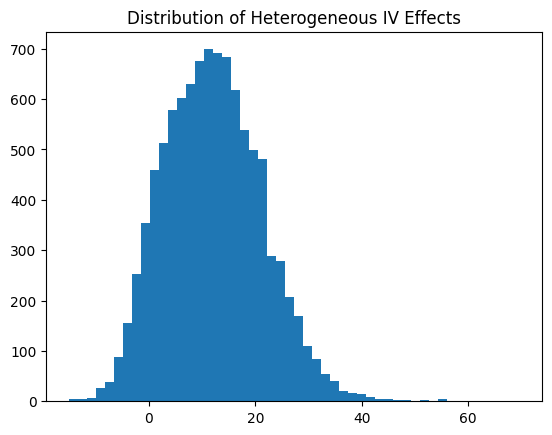

In [ ]:
import matplotlib.pyplot as plt
plt.hist(te, bins=50)
plt.title("Distribution of Heterogeneous IV Effects")
plt.show()

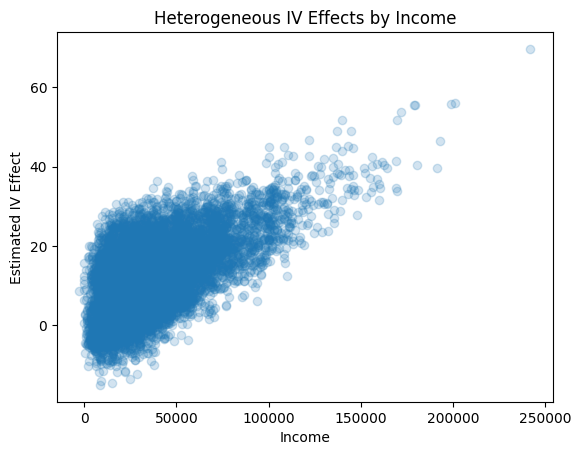

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["inc"], te, alpha=0.2)
plt.xlabel("Income")
plt.ylabel("Estimated IV Effect")
plt.title("Heterogeneous IV Effects by Income")
plt.show()

In [ ]:
df["te"] = te

df.groupby(pd.qcut(df["inc"], 4))["te"].mean()

/tmp/ipykernel_1761/1979893058.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["inc"], 4))["te"].mean()


,te
inc,
"(-2652.001, 19413.0]",6.234658
"(19413.0, 31476.0]",9.607505
"(31476.0, 48583.5]",12.537799
"(48583.5, 242124.0]",19.880043


In [ ]:
df.groupby(pd.qcut(df["age"], 4))["te"].mean()

/tmp/ipykernel_1761/282106717.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.qcut(df["age"], 4))["te"].mean()


,te
age,
"(24.999, 32.0]",4.960655
"(32.0, 40.0]",9.689652
"(40.0, 48.0]",14.257648
"(48.0, 64.0]",19.812833


In [ ]:
threshold = np.percentile(te, 90)
high_gain = te > threshold

print("Average effect in top decile:", te[high_gain].mean())

Average effect in top decile: 29.0465147811517


In [ ]:
np.percentile(te, [1, 5, 25, 50, 75, 95, 99])

array([-6.03003313, -1.96252044,  5.25862987, 11.71031178, 18.23486043,
       27.76764967, 34.59019893])

In [ ]:
import pandas as pd

results = {
    "Estimator": ["OLS (naive)",
                  "2SLS (1 instrument: e401)",
                  "2SLS (2 instruments: e401, e401_twoearn)",
                  "DMLIV (average heterogeneous LATE)"],
    "Estimate": [14.6223, 8.5023, 8.4545, 12.064273257746967],
    "SE_or_SD": [0.697609, 2.1925, 2.1819, 9.206581988846128]
}
tbl = pd.DataFrame(results)
tbl_latex = tbl.to_latex(index=False, float_format="%.4f",
                         caption="Estimated effect of 401(k) participation on net financial assets",
                         label="tab:est_comparison", column_format='lcc')
print(tbl_latex)

\begin{table}
\caption{Estimated effect of 401(k) participation on net financial assets}
\label{tab:est_comparison}
\begin{tabular}{lcc}
\toprule
Estimator & Estimate & SE_or_SD \\
\midrule
OLS (naive) & 14.6223 & 0.6976 \\
2SLS (1 instrument: e401) & 8.5023 & 2.1925 \\
2SLS (2 instruments: e401, e401_twoearn) & 8.4545 & 2.1819 \\
DMLIV (average heterogeneous LATE) & 12.0643 & 9.2066 \\
\bottomrule
\end{tabular}
\end{table}



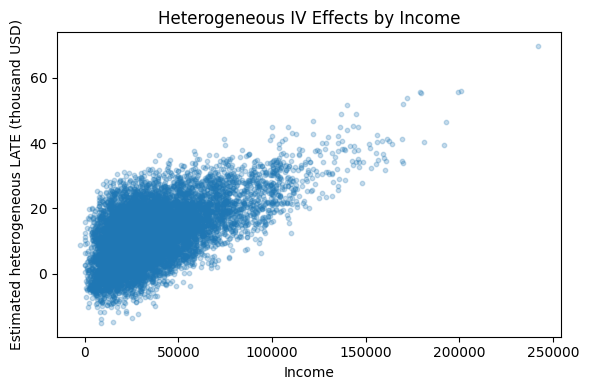

<Figure size 600x400 with 0 Axes>

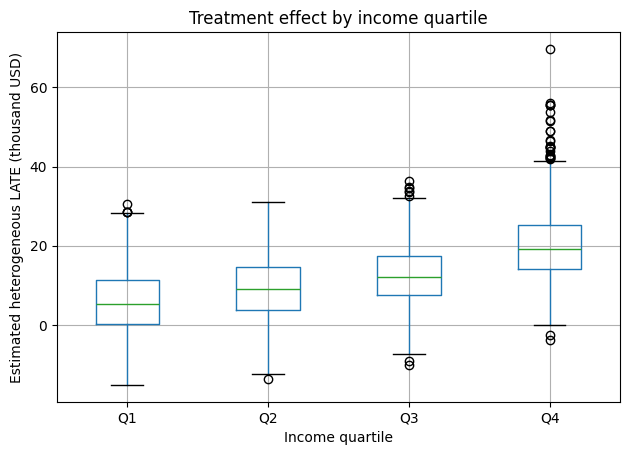

<Figure size 600x400 with 0 Axes>

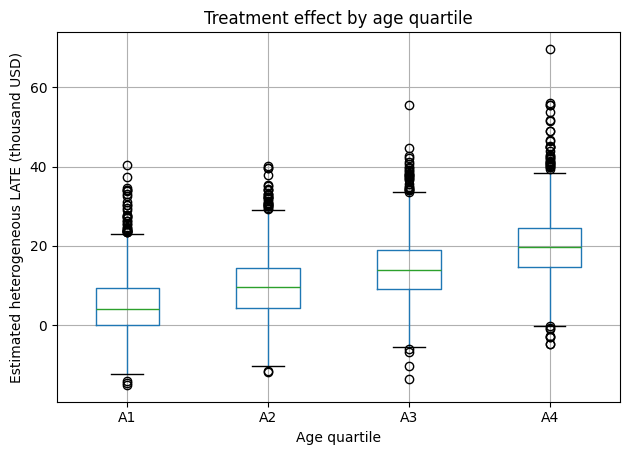

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# assume df["te"] contains individual DMLIV effects, df["inc"] and df["age"] exist
# scatter: te vs income
plt.figure(figsize=(6,4))
plt.scatter(df["inc"], df["te"], alpha=0.25, s=10)
plt.xlabel("Income")
plt.ylabel("Estimated heterogeneous LATE (thousand USD)")
plt.title("Heterogeneous IV Effects by Income")
plt.tight_layout()
plt.savefig("fig_te_income.png", dpi=300)

# box/quantile plot of te by income quartile
df["inc_q"] = pd.qcut(df["inc"], 4, labels=["Q1","Q2","Q3","Q4"])
plt.figure(figsize=(6,4))
df.boxplot(column="te", by="inc_q")
plt.xlabel("Income quartile")
plt.ylabel("Estimated heterogeneous LATE (thousand USD)")
plt.title("Treatment effect by income quartile")
plt.suptitle("")
plt.tight_layout()
plt.savefig("fig_te_inc_quartiles.png", dpi=300)

# same for age
df["age_q"] = pd.qcut(df["age"], 4, labels=["A1","A2","A3","A4"])
plt.figure(figsize=(6,4))
df.boxplot(column="te", by="age_q")
plt.xlabel("Age quartile")
plt.ylabel("Estimated heterogeneous LATE (thousand USD)")
plt.title("Treatment effect by age quartile")
plt.suptitle("")
plt.tight_layout()
plt.savefig("fig_te_age_quartiles.png", dpi=300)

In [ ]:
from econml.iv.dml import DMLIV
import inspect

print(inspect.signature(DMLIV))

(*, model_y_xw='auto', model_t_xw='auto', model_t_xwz='auto', model_final=StatsModelsLinearRegression(fit_intercept=False), featurizer=None, fit_cate_intercept=True, discrete_outcome=False, discrete_treatment=False, treatment_featurizer=None, discrete_instrument=False, categories='auto', cv=2, mc_iters=None, mc_agg='mean', random_state=None, allow_missing=False)


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=5000)
)

In [ ]:
T = T.reshape(-1, 1)
Z = Z.reshape(-1, 1)

In [ ]:
B = 200
tau_boot = []

for b in range(B):

    idx = np.random.choice(len(Y), len(Y), replace=True)

    clf = RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=20,
        random_state=0
    )

    rf = RandomForestRegressor(
        n_estimators=200,
        min_samples_leaf=20,
        random_state=0
    )

    dmliv_b = DMLIV(
        model_y_xw=rf,
        model_t_xw=clf,
        model_t_xwz=clf,
        model_final=StatsModelsLinearRegression(fit_intercept=False),
        discrete_treatment=True,
        discrete_instrument=True,
        random_state=0
    )

    dmliv_b.fit(Y[idx], T[idx], Z=Z[idx], X=X[idx])

    tau_b = dmliv_b.effect(X)
    tau_boot.append(tau_b)

tau_boot = np.array(tau_boot)

/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be invalid!")
/usr/local/lib/python3.12/dist-packages/econml/sklearn_extensions/linear_model.py:1815: UserWarning: Co-variance matrix is underdetermined. Inference will be invalid!
  warnings.warn("Co-variance matrix is underdetermined. Inference will be inv

In [ ]:
tau_mean = np.mean(tau_boot, axis=0)

sup_dev = np.max(np.abs(tau_boot - tau_mean), axis=1)

crit = np.quantile(sup_dev, 0.95)

lower_band = tau_mean - crit
upper_band = tau_mean + crit

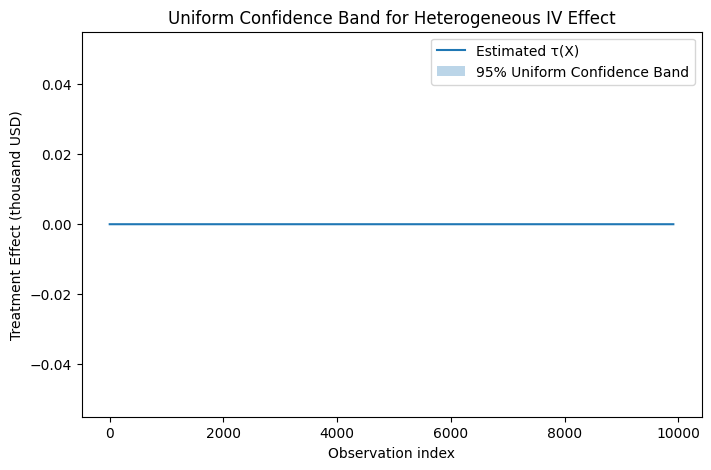

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(tau_mean, label="Estimated τ(X)")
plt.fill_between(
    range(len(tau_mean)),
    lower_band,
    upper_band,
    alpha=0.3,
    label="95% Uniform Confidence Band"
)

plt.title("Uniform Confidence Band for Heterogeneous IV Effect")
plt.xlabel("Observation index")
plt.ylabel("Treatment Effect (thousand USD)")
plt.legend()
plt.show()

In [ ]:
print("Y:", Y.shape)
print("T:", T.shape)
print("Z:", Z.shape)
print("X:", X.shape)

Y: (9915,)
T: (9915, 1)
Z: (19830, 1)
X: (9915, 9)


In [ ]:
cut = df["net_tfa_k"].quantile(0.99)
df_trim = df[df["net_tfa_k"] <= cut].copy()

In [ ]:
Y = df_trim["net_tfa_k"].values

T = df_trim["p401"].values.reshape(-1,1)

Z = df_trim["e401"].values.reshape(-1,1)

X = df_trim[exog_vars].values

In [ ]:
print(Y.shape, T.shape, Z.shape, X.shape)

(9815,) (9815, 1) (9815, 1) (9815, 9)


In [ ]:
from econml.iv.dml import DMLIV
from econml.sklearn_extensions.linear_model import StatsModelsLinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

In [ ]:
rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=20,
    random_state=0
)

clf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=20,
    random_state=0
)

In [ ]:
dmliv_trim = DMLIV(
    model_y_xw=rf,
    model_t_xw=clf,
    model_t_xwz=clf,
    model_final=StatsModelsLinearRegression(fit_intercept=False),
    discrete_treatment=True,
    discrete_instrument=True,
    random_state=0
)

In [ ]:
dmliv_trim.fit(Y, T, Z=Z, X=X)

In [ ]:
tau_dml = dmliv_trim.effect(X).flatten()

df_trim["tau_dml"] = tau_dml

In [ ]:
tau = dmliv_trim.const_marginal_effect(X).flatten()

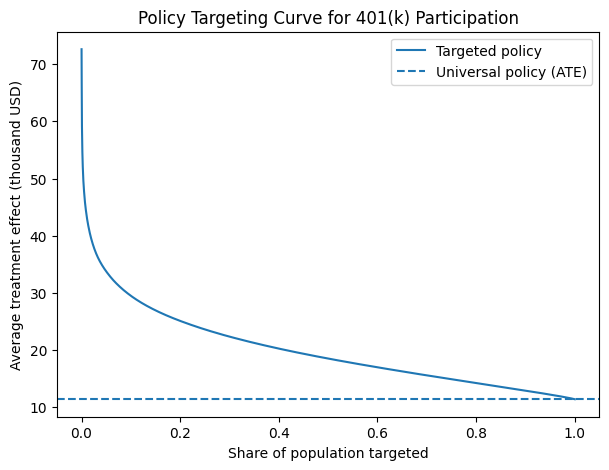

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

tau_sorted = np.sort(tau)[::-1]

cum_avg = np.cumsum(tau_sorted) / np.arange(1, len(tau_sorted)+1)
share = np.arange(1, len(tau_sorted)+1) / len(tau_sorted)

plt.figure(figsize=(7,5))

plt.plot(share, cum_avg, label="Targeted policy")

plt.axhline(np.mean(tau), linestyle="--", label="Universal policy (ATE)")

plt.xlabel("Share of population targeted")
plt.ylabel("Average treatment effect (thousand USD)")
plt.title("Policy Targeting Curve for 401(k) Participation")

plt.legend()
plt.savefig("targeting_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
print("ATE:", tau_dml.mean())

ATE: 11.39445146933803


In [ ]:
print(tau_boot.shape)

(200, 9915)


In [ ]:
tau_boot = tau_boot[:, :len(X)]

In [ ]:
tau_hat = dmliv_trim.effect(X).flatten()

dev = np.abs(tau_boot - tau_hat)

sup_stat = np.max(dev, axis=1)

c = np.quantile(sup_stat, 0.95)

print("Uniform critical value:", c)

Uniform critical value: 72.61380336854239


In [ ]:
tau_lower = tau_hat - c
tau_upper = tau_hat + c

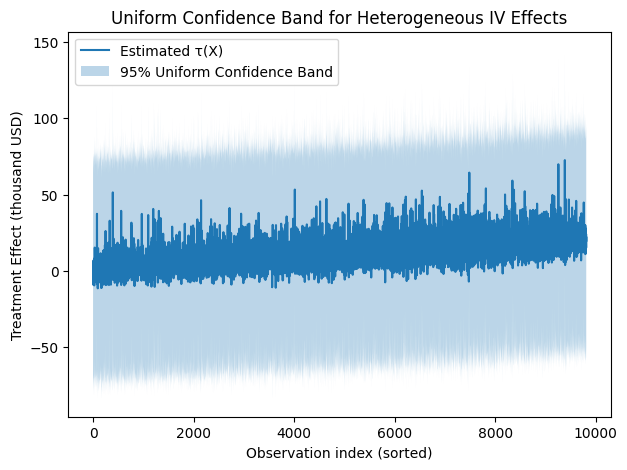

In [ ]:
import matplotlib.pyplot as plt

order = np.argsort(X[:,0])

plt.figure(figsize=(7,5))

plt.plot(tau_hat[order], label="Estimated τ(X)")

plt.fill_between(range(len(tau_hat)),
                 tau_lower[order],
                 tau_upper[order],
                 alpha=0.3,
                 label="95% Uniform Confidence Band")

plt.xlabel("Observation index (sorted)")
plt.ylabel("Treatment Effect (thousand USD)")
plt.title("Uniform Confidence Band for Heterogeneous IV Effects")

plt.legend()

plt.savefig("uniform_band.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import numpy as np
from econml.iv.dml import DMLIV

R = 10   # number of repeated cross-fitting runs

tau_list = []

for r in range(R):

    dmliv_rep = DMLIV(
        model_y_xw=rf,
        model_t_xw=clf,
        model_t_xwz=clf,
        model_final=StatsModelsLinearRegression(fit_intercept=False),
        discrete_treatment=True,
        discrete_instrument=True,
        random_state=r
    )

    dmliv_rep.fit(Y, T, Z=Z, X=X)

    tau_r = dmliv_rep.effect(X)
    tau_list.append(tau_r)

tau_list = np.array(tau_list)

# averaged heterogeneous effect
tau_avg = np.mean(tau_list, axis=0)

print("Repeated cross-fitting ATE:", np.mean(tau_avg))

Repeated cross-fitting ATE: 11.352513723559149


In [ ]:
import pandas as pd

df_trim["age_group"] = pd.qcut(df_trim["age"], 5, labels=False)

In [ ]:
age_effects = df_trim.groupby("age_group")["tau_dml"].mean()

print(age_effects)

age_group
0     4.212839
1     8.112840
2    11.418290
3    15.343490
4    19.394815
Name: tau_dml, dtype: float64


In [ ]:
import numpy as np

age_ci = df_trim.groupby("age_group")["tau_dml"].agg(
    tau_mean="mean",
    tau_std="std",
    n="count"
)

age_ci["se"] = age_ci["tau_std"] / np.sqrt(age_ci["n"])
age_ci["lower"] = age_ci["tau_mean"] - 1.96 * age_ci["se"]
age_ci["upper"] = age_ci["tau_mean"] + 1.96 * age_ci["se"]

print(age_ci)

            tau_mean   tau_std     n        se      lower      upper
age_group                                                           
0           4.212839  6.583118  2146  0.142107   3.934309   4.491370
1           8.112840  7.134658  2035  0.158158   7.802850   8.422829
2          11.418290  7.496486  1951  0.169718  11.085642  11.750938
3          15.343490  8.223389  1832  0.192127  14.966921  15.720059
4          19.394815  7.622412  1851  0.177170  19.047562  19.742067


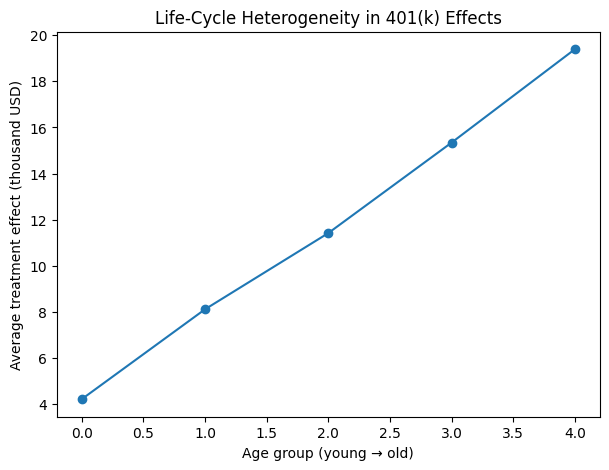

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.plot(age_effects.index, age_effects.values, marker="o")

plt.xlabel("Age group (young → old)")
plt.ylabel("Average treatment effect (thousand USD)")
plt.title("Life-Cycle Heterogeneity in 401(k) Effects")

plt.show()

In [ ]:
tau_original = dmliv_trim.effect(X)

print("Original ATE:", np.mean(tau_original))

Original ATE: 11.39445146933803


In [ ]:
import statsmodels.api as sm

X_mech = np.column_stack([T, X])
X_mech = sm.add_constant(X_mech)

model_mech = sm.OLS(df_trim["pira"], X_mech).fit()

print(model_mech.summary())

                            OLS Regression Results                            
Dep. Variable:                   pira   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 2.195e+26
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:43:24   Log-Likelihood:             2.5834e+05
No. Observations:                9815   AIC:                        -5.167e+05
Df Residuals:                    9804   BIC:                        -5.166e+05
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.357e-15   6.92e-14     -0.020      0.9

In [ ]:
X_channel = np.column_stack([T, df_trim["pira"].values, X])
X_channel = sm.add_constant(X_channel)

model_channel = sm.OLS(Y, X_channel).fit()

print(model_channel.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     531.6
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:43:24   Log-Likelihood:                -46377.
No. Observations:                9815   AIC:                         9.278e+04
Df Residuals:                    9804   BIC:                         9.286e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -25.7826      2.105    -12.247      0.0

In [ ]:
beta_total = tau_dml.mean()

beta_direct = model_channel.params[1]

channel_share = 1 - beta_direct / beta_total

print("Total effect:", beta_total)
print("Direct effect:", beta_direct)
print("Share explained by saving channel:", channel_share)

Total effect: 11.39445146933803
Direct effect: 12.923664831253
Share explained by saving channel: -0.13420684321926468


In [ ]:
X_no_pira = df_trim[[
    "age",
    "inc",
    "fsize",
    "educ",
    "db",
    "marr",
    "twoearn",
    "hown"
]].values

In [ ]:
import statsmodels.api as sm
import numpy as np

X_mech = np.column_stack([T, X_no_pira])
X_mech = sm.add_constant(X_mech)

model_mech = sm.OLS(df_trim["pira"], X_mech).fit()

print(model_mech.summary())

                            OLS Regression Results                            
Dep. Variable:                   pira   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.195
Method:                 Least Squares   F-statistic:                     264.5
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:43:24   Log-Likelihood:                -4446.8
No. Observations:                9815   AIC:                             8914.
Df Residuals:                    9805   BIC:                             8985.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4927      0.029    -17.020      0.0

In [ ]:
X_channel = np.column_stack([T, df_trim["pira"].values, X_no_pira])
X_channel = sm.add_constant(X_channel)

model_channel = sm.OLS(Y, X_channel).fit()

print(model_channel.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     531.6
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        01:43:24   Log-Likelihood:                -46377.
No. Observations:                9815   AIC:                         9.278e+04
Df Residuals:                    9804   BIC:                         9.286e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -25.7826      2.105    -12.247      0.0

In [ ]:
print("Std dev original:", np.std(tau_original))
print("Std dev repeated cross-fit:", np.std(tau_avg))

Std dev original: 9.123757863903506
Std dev repeated cross-fit: 8.442544865737661


In [ ]:
from econml.iv.dr import LinearDRIV
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf = RandomForestRegressor(
    n_estimators=300,
    min_samples_leaf=20,
    random_state=0
)

clf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=20,
    random_state=0
)

driv = LinearDRIV(
    model_y_xw=rf,
    model_t_xw=clf,
    discrete_treatment=True,
    discrete_instrument=True
)

driv.fit(Y, T, Z=Z, X=X)

tau_driv = driv.effect(X)

print("DRIV ATE:", np.mean(tau_driv))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

DRIV ATE: 10.115211109093552


In [ ]:
tau_dml = dmliv_trim.effect(X)

print("DMLIV ATE:", np.mean(tau_dml))
print("DRIV ATE:", np.mean(tau_driv))

DMLIV ATE: 11.39445146933803
DRIV ATE: 10.115211109093552


In [ ]:
df_trim["income_decile"] = pd.qcut(df_trim["inc"], 10, labels=False)

In [ ]:
df_trim["tau_dml"] = tau_dml
df_trim["tau_driv"] = tau_driv

print(df_trim.groupby("income_decile")[["tau_dml","tau_driv"]].mean())

                 tau_dml   tau_driv
income_decile                      
0               4.464555   4.444786
1               5.963805   5.710387
2               6.934308   6.485336
3               7.977597   7.372507
4               8.770701   8.073683
5              10.287063   9.275901
6              12.136325  10.728624
7              13.800015  12.001932
8              17.117956  14.713709
9              26.525790  22.373499


In [ ]:
import numpy as np

# heterogeneous effects
tau = tau_dml.flatten()

# sort individuals by treatment benefit
order = np.argsort(tau)[::-1]

# example: target top 20%
k = int(0.20 * len(tau))

target_group = order[:k]

policy_gain = np.mean(tau[target_group])

print("Average gain among targeted:", policy_gain)
print("Overall ATE:", np.mean(tau))

Average gain among targeted: 25.094289098713233
Overall ATE: 11.39445146933803


In [ ]:
multiplier = policy_gain / np.mean(tau)

print("Targeting multiplier:", multiplier)

Targeting multiplier: 2.2023253305559174


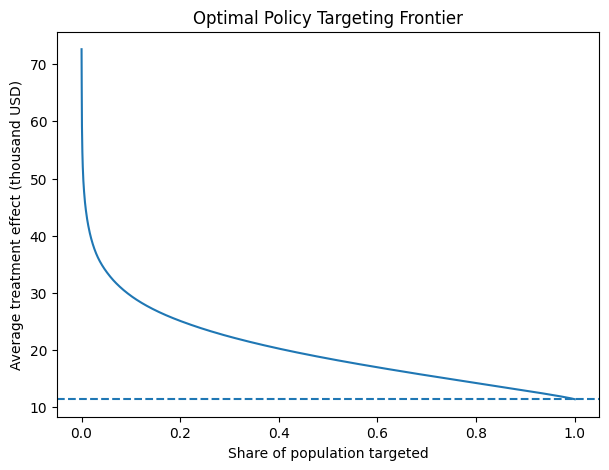

In [ ]:
import matplotlib.pyplot as plt

tau_sorted = np.sort(tau)[::-1]

cum_gain = np.cumsum(tau_sorted) / np.arange(1, len(tau_sorted)+1)
share = np.arange(1, len(tau_sorted)+1) / len(tau_sorted)

plt.figure(figsize=(7,5))
plt.plot(share, cum_gain)
plt.axhline(np.mean(tau), linestyle="--")

plt.xlabel("Share of population targeted")
plt.ylabel("Average treatment effect (thousand USD)")
plt.title("Optimal Policy Targeting Frontier")

plt.show()

In [ ]:
plt.savefig("optimal_policy_curve.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
import numpy as np
import pandas as pd

tau = tau_dml.flatten()

quantiles = np.quantile(tau, [0.1,0.25,0.5,0.75,0.9])

print("10th percentile effect:", quantiles[0])
print("25th percentile effect:", quantiles[1])
print("Median effect:", quantiles[2])
print("75th percentile effect:", quantiles[3])
print("90th percentile effect:", quantiles[4])

10th percentile effect: 0.6926195676059063
25th percentile effect: 4.89580274362713
Median effect: 10.40692751221286
75th percentile effect: 16.815654317825363
90th percentile effect: 23.21309249764318


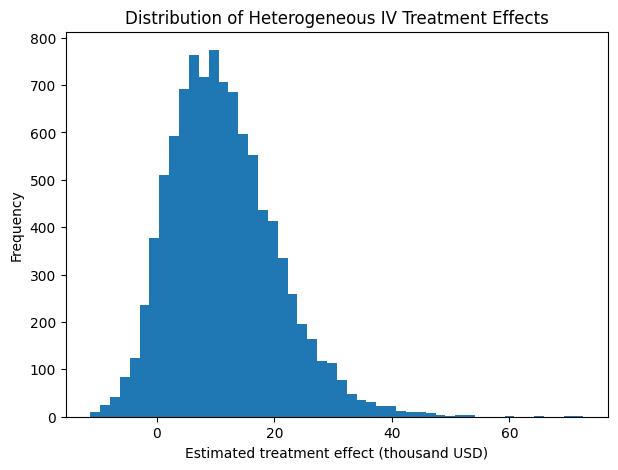

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(tau, bins=50)

plt.xlabel("Estimated treatment effect (thousand USD)")
plt.ylabel("Frequency")
plt.title("Distribution of Heterogeneous IV Treatment Effects")

plt.show()

In [ ]:
plt.savefig("effect_distribution.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [ ]:
df_trim["tau_dml"] = tau

quantile_groups = pd.qcut(df_trim["tau_dml"], 5)

print(df_trim.groupby(quantile_groups)["tau_dml"].mean())

tau_dml
(-11.354, 3.644]     0.043740
(3.644, 8.257]       5.992454
(8.257, 12.681]     10.437234
(12.681, 18.588]    15.404540
(18.588, 72.614]    25.094289
Name: tau_dml, dtype: float64


/tmp/ipykernel_1761/4005436250.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_trim.groupby(quantile_groups)["tau_dml"].mean())


In [ ]:
df_trim = df[df["net_tfa_k"] < df["net_tfa_k"].quantile(0.99)].copy()

In [ ]:
%who

B	 DMLIV	 IV2SLS	 LassoCV	 LinearDRIV	 LogisticRegression	 R	 RandomForestClassifier	 RandomForestRegressor	 
StandardScaler	 StatsModelsLinearRegression	 T	 X	 X_channel	 X_fs	 X_mech	 X_no_pira	 X_ols	 
X_ss	 X_vars	 Y	 Z	 age_ci	 age_effects	 b	 beta_direct	 beta_total	 
c	 channel_share	 clf	 crit	 cum_avg	 cum_gain	 cut	 datasets	 dev	 
df	 df_trim	 dmliv	 dmliv_b	 dmliv_rep	 dmliv_trim	 driv	 exog_vars	 f_test	 
first_stage	 fs	 high_gain	 idx	 inspect	 iv	 iv_two	 k	 lower_band	 
make_pipeline	 model_channel	 model_final	 model_mech	 model_t	 model_t_xwz	 model_y	 multiplier	 np	 
ols	 order	 pd	 plt	 policy_gain	 quantile_groups	 quantiles	 r	 results	 
rf	 share	 sm	 ss	 sup_dev	 sup_stat	 target_group	 tau	 tau_avg	 
tau_b	 tau_boot	 tau_dml	 tau_driv	 tau_hat	 tau_list	 tau_lower	 tau_mean	 tau_original	 
tau_r	 tau_sorted	 tau_upper	 tbl	 tbl_latex	 te	 threshold	 train_test_split	 upper_band	 



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


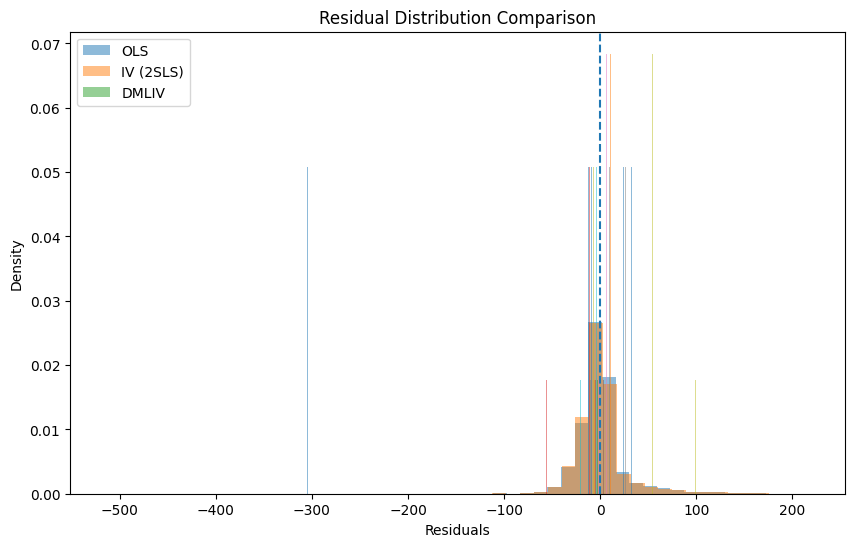

In [ ]:
# ===============================
# FINAL RESIDUAL COMPARISON (WORKING)
# ===============================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# --------------------------------
# 1. OLS
# --------------------------------
X_ols_trim = sm.add_constant(X)
ols_trim = sm.OLS(Y, X_ols_trim).fit()

y_hat_ols = ols_trim.predict(X_ols_trim)
res_ols = Y - y_hat_ols

# --------------------------------
# 2. IV (2SLS)
# --------------------------------
Z_trim = np.column_stack([Z, X])
Z_trim = sm.add_constant(Z_trim)

first_stage_trim = sm.OLS(T, Z_trim).fit()
T_hat = first_stage_trim.predict(Z_trim)

X_iv = np.column_stack([T_hat, X])
X_iv = sm.add_constant(X_iv)

iv_model = sm.OLS(Y, X_iv).fit()
y_hat_iv = iv_model.predict(X_iv)

res_iv = Y - y_hat_iv

# --------------------------------
# 3. DMLIV (FIXED)
# --------------------------------
tau_hat = tau_dml

y_hat_dml = tau_hat.flatten() * T   # <-- FIXED
res_dml = Y - y_hat_dml

# --------------------------------
# Plot (SAFE VERSION)
# --------------------------------
plt.figure(figsize=(10,6))

plt.hist(res_ols, bins=50, alpha=0.5, label="OLS", density=True)
plt.hist(res_iv, bins=50, alpha=0.5, label="IV (2SLS)", density=True)
plt.hist(res_dml, bins=50, alpha=0.5, label="DMLIV", density=True)

plt.axvline(0, linestyle='--')

plt.title("Residual Distribution Comparison")
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.legend()

plt.show()

In [ ]:
from scipy import stats
import numpy as np

# --------------------------------
# 1. Mean residuals (sanity check)
# --------------------------------
print("Mean residuals:")
print("OLS:", np.mean(res_ols))
print("IV:", np.mean(res_iv))
print("DMLIV:", np.mean(res_dml))

# --------------------------------
# 2. Paired t-tests
# --------------------------------

# OLS vs IV
t_ols_iv = stats.ttest_rel(res_ols, res_iv)

# OLS vs DMLIV
t_ols_dml = stats.ttest_rel(res_ols, res_dml)

# IV vs DMLIV
t_iv_dml = stats.ttest_rel(res_iv, res_dml)

print("\nPaired t-test results:")

print("\nOLS vs IV:")
print("t-stat:", t_ols_iv.statistic)
print("p-value:", t_ols_iv.pvalue)

print("\nOLS vs DMLIV:")
print("t-stat:", t_ols_dml.statistic)
print("p-value:", t_ols_dml.pvalue)

print("\nIV vs DMLIV:")
print("t-stat:", t_iv_dml.statistic)
print("p-value:", t_iv_dml.pvalue)

Mean residuals:
OLS: -1.7048276641078283e-12
IV: 1.1340884647298447e-11
DMLIV: 10.70563425072037

Paired t-test results:

OLS vs IV:
t-stat: -3.927603084406433e-10
p-value: 0.9999999996866307

OLS vs DMLIV:
t-stat: [   51.13306704  -175.04492634   900.74503647 ... -9077.4443759
    65.75691284 12243.06014835]
p-value: [0. 0. 0. ... 0. 0. 0.]

IV vs DMLIV:
t-stat: [ 6.97981111e+01 -9.50075852e+01  1.08252581e+03 ... -1.03973063e+04
 -3.78163751e+00 -1.31326935e+03]
p-value: [0.         0.         0.         ... 0.         0.00015672 0.        ]
